In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    classification_report
)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (63874, 51)
Test shape: (9043, 51)


In [3]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)

print("✅ Modelo Logistic Regression creado")

✅ Modelo Logistic Regression creado


In [4]:
log_model.fit(X_train, y_train)

print("✅ Modelo entrenado")

✅ Modelo entrenado


In [5]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("✅ Predicciones generadas")

✅ Predicciones generadas


In [6]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc       = roc_auc_score(y_test, y_prob)

metrics = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score","ROC AUC"],
    "Score":[accuracy,precision,recall,f1,roc]
})

metrics

,Metric,Score
0,Accuracy,0.745660
1,Precision,0.260232
2,Recall,0.637051
3,F1 Score,0.369518
4,ROC AUC,0.767464


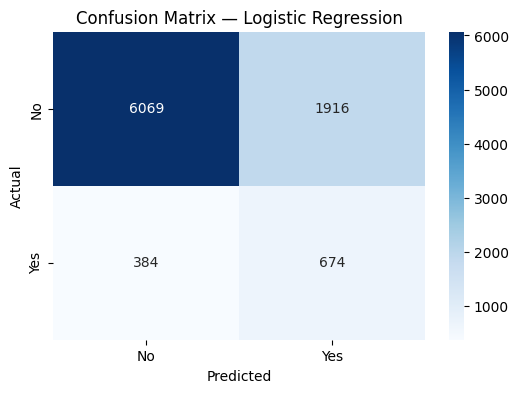

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

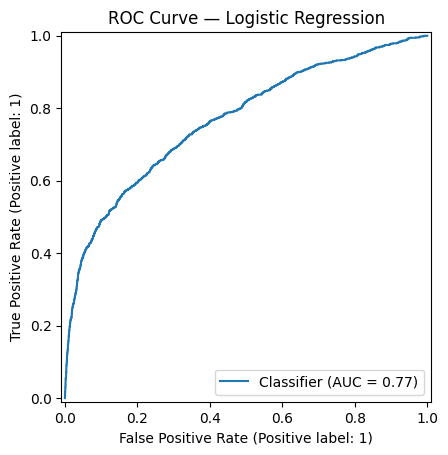

In [9]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve — Logistic Regression")
plt.show()

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      7985
           1       0.26      0.64      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043



In [11]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(log_model, "../models/logistic_regression.pkl")

print("✅ Modelo guardado en models/logistic_regression.pkl")

✅ Modelo guardado en models/logistic_regression.pkl
